# 01 — Explore CICIDS2017

Goal of this notebook: just *look* at the data before training anything. This is where most of the learning happens.

**Before running:** download the CICIDS2017 MachineLearningCVE CSVs into `../data/` (see `../data/README.md`).

Run this notebook from the `notebooks/` folder.

In [1]:
import sys
from pathlib import Path
# Let the notebook import our project code in ../src
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import config

pd.set_option('display.max_columns', None)

In [2]:
# Load only the columns we need (features + label) to keep memory manageable.
needed_cols = set(config.SURICATA_ALIGNED_FEATURES + [config.LABEL_COLUMN])
csv_paths = sorted(config.DATA_DIR.glob('**/*.csv'))
print(f'Found {len(csv_paths)} CSV files')

frames = []
for p in csv_paths:
    frame = pd.read_csv(p, usecols=lambda col: col.strip() in needed_cols, low_memory=False)
    frame.columns = [c.strip() for c in frame.columns]
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=config.SURICATA_ALIGNED_FEATURES)
print(df.shape)
df.head()

Found 8 CSV files
(2827876, 11)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Label
0,54865,3,2,0,12,0,6.0,0.0,4.000000e+06,666666.66670,BENIGN
1,55054,109,1,1,6,6,6.0,6.0,1.100917e+05,18348.62385,BENIGN
2,55055,52,1,1,6,6,6.0,6.0,2.307692e+05,38461.53846,BENIGN
3,46236,34,1,1,6,6,6.0,6.0,3.529412e+05,58823.52941,BENIGN
4,54863,3,2,0,12,0,6.0,0.0,4.000000e+06,666666.66670,BENIGN


## What attack types are in here, and how (im)balanced is it?
Real network traffic is mostly normal, so 'BENIGN' will dominate. Notice this — it's why plain accuracy can be misleading.

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


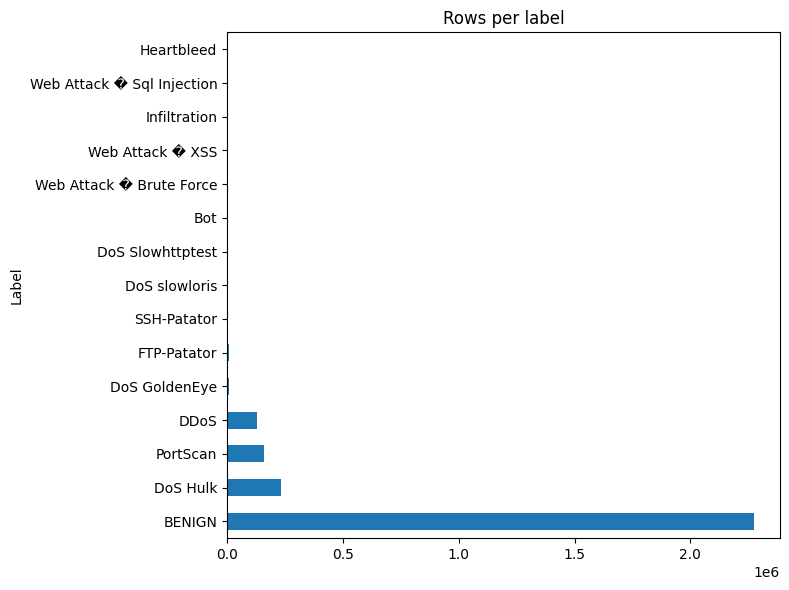

In [3]:
label_counts = df[config.LABEL_COLUMN].str.strip().value_counts()
print(label_counts)
label_counts.plot(kind='barh', figsize=(8,6), title='Rows per label')
plt.tight_layout()

## The features we'll actually use
We deliberately train on only the features Suricata can give us live (in `config.SURICATA_ALIGNED_FEATURES`). Let's look at those.

In [3]:
feat = df[config.SURICATA_ALIGNED_FEATURES].replace([np.inf, -np.inf], np.nan)
feat.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Fwd Packet Length Mean,Bwd Packet Length Mean
count,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06,2.827876e+06
mean,8.061534e+03,1.480065e+07,9.368972e+00,1.040396e+01,5.498522e+02,1.617903e+04,1.491719e+06,7.085423e+04,5.825628e+01,3.062575e+02
std,1.827432e+04,3.366750e+07,7.500527e+02,9.978937e+02,9.998639e+03,2.264235e+06,2.594016e+07,2.544154e+05,1.861733e+02,6.054855e+02
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.610000e+08,-2.000000e+06,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,2.000000e+00,1.192924e+02,3.415323e+00,6.000000e+00,2.000000e+00
50%,8.000000e+01,3.133800e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,4.586601e+03,1.094760e+02,3.400000e+01,7.200000e+01
75%,4.430000e+02,3.239368e+06,5.000000e+00,4.000000e+00,1.880000e+02,4.840000e+02,1.666667e+05,2.325581e+04,5.000000e+01,1.810000e+02
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.071000e+09,4.000000e+06,5.940857e+03,5.800500e+03


Text(0.5, 1.0, 'Forward packets: benign (False) vs attack (True)')

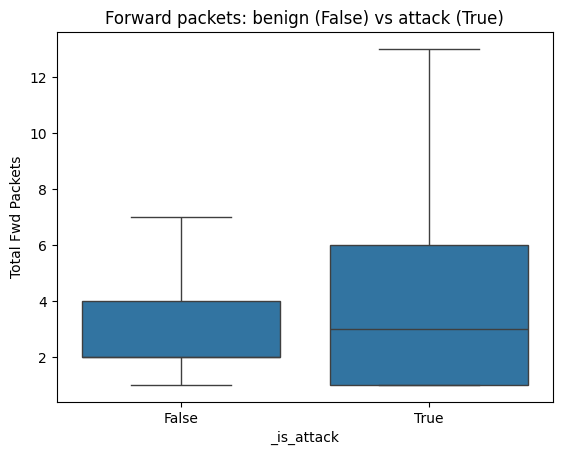

In [5]:
# How do a couple of features differ between benign and attack traffic?
df['_is_attack'] = (df[config.LABEL_COLUMN].str.strip() != config.BENIGN_LABEL)
sns.boxplot(data=df, x='_is_attack', y='Total Fwd Packets', showfliers=False)
plt.title('Forward packets: benign (False) vs attack (True)')

When you're comfortable with what the data looks like, move on to **`02_train.ipynb`**.